In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [8]:
# Data loaders for CIFAR-10
def get_cifar10_loaders(batch_size=128, num_workers=2):
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test)

    trainloader = DataLoader(trainset, batch_size=batch_size,
                             shuffle=True, num_workers=num_workers)
    testloader = DataLoader(testset, batch_size=batch_size,
                            shuffle=False, num_workers=num_workers)
    return trainloader, testloader

In [9]:
# Architecture
class IntermediateBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_branches=3):
        super(IntermediateBlock, self).__init__()
        self.num_branches = num_branches

        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for _ in range(num_branches)
        ])
        self.weight_fc = nn.Linear(in_channels, num_branches)

    def forward(self, x):
        m = x.mean(dim=(2, 3))
        a = F.softmax(self.weight_fc(m), dim=1)
        out = 0
        branch_outputs = [branch(x) for branch in self.branches]
        for i in range(self.num_branches):
            ai = a[:, i].view(-1, 1, 1, 1)
            out += ai * branch_outputs[i]
        return out


class CustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomCNN, self).__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True))


        self.b1 = IntermediateBlock(64, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.b2 = IntermediateBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.b3 = IntermediateBlock(128, 128)

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes))

    def forward(self, x):
        x = self.stem(x)
        x = self.pool1(self.b1(x))
        x = self.pool2(self.b2(x))
        x = self.b3(x)
        m = x.mean(dim=(2, 3))
        return self.classifier(m)

In [10]:
def train_and_test(model, dataloader, optimizer, loss_fn, device, training, batch_losses=None):
    model.train() if training else model.eval()
    running_loss = correct = total = 0

    with torch.set_grad_enabled(training):
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)

            if training:
                optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            if training:
                loss.backward()
                optimizer.step()
                if batch_losses is not None:
                    batch_losses.append(loss.item())

            running_loss += loss.item() * inputs.size(0)
            correct += outputs.max(1)[1].eq(targets).sum().item()
            total += targets.size(0)

    return running_loss / total, correct / total

In [11]:
def train_model(epochs=50, batch_size=128, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    trainloader, testloader = get_cifar10_loaders(batch_size=batch_size)

    model = CustomCNN().to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    history = {'train_loss': [], 'test_loss': [],
               'train_acc': [],  'test_acc':  []}
    batch_losses = []
    best_test_acc = 0.0

    for epoch in range(epochs):
        train_loss, train_acc = train_and_test(
            model, trainloader, optimizer, loss_fn, device,
            training=True, batch_losses=batch_losses)
        test_loss, test_acc = train_and_test(
            model, testloader, optimizer, loss_fn, device, training=False)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc * 100)
        history['test_acc'].append(test_acc * 100)
        best_test_acc = max(best_test_acc, test_acc * 100)

        print(f"Epoch {epoch+1:3d}/{epochs}: "
              f"train_loss={train_loss:.4f} test_loss={test_loss:.4f}  "
              f"train_acc={train_acc*100:.2f}% test_acc={test_acc*100:.2f}%  "
              f"(best test acc so far: {best_test_acc:.2f}%)")
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    axes[0].plot(batch_losses)
    axes[0].set_title("Training loss per batch")
    axes[0].set_xlabel("Batch")
    axes[0].set_ylabel("Loss")

    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['test_acc'],  label='Test')
    axes[1].set_title("Accuracy per epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("training_curves.png")
    plt.show()


    print(f"\nFinal best test accuracy: {best_test_acc:.2f}%")


    return model, history, batch_losses

Using device: cuda
Epoch   1/50: train_loss=1.5826 test_loss=1.5144  train_acc=41.03% test_acc=46.53%  (best test acc so far: 46.53%)
Epoch   2/50: train_loss=1.2171 test_loss=1.2934  train_acc=56.91% test_acc=54.42%  (best test acc so far: 54.42%)
Epoch   3/50: train_loss=1.0633 test_loss=1.9500  train_acc=62.53% test_acc=44.86%  (best test acc so far: 54.42%)
Epoch   4/50: train_loss=0.9701 test_loss=1.6332  train_acc=66.42% test_acc=48.85%  (best test acc so far: 54.42%)
Epoch   5/50: train_loss=0.8964 test_loss=1.2927  train_acc=69.25% test_acc=58.54%  (best test acc so far: 58.54%)
Epoch   6/50: train_loss=0.8470 test_loss=1.5962  train_acc=71.14% test_acc=49.29%  (best test acc so far: 58.54%)
Epoch   7/50: train_loss=0.7985 test_loss=0.9500  train_acc=72.71% test_acc=68.49%  (best test acc so far: 68.49%)
Epoch   8/50: train_loss=0.7552 test_loss=0.8957  train_acc=74.37% test_acc=69.68%  (best test acc so far: 69.68%)
Epoch   9/50: train_loss=0.7281 test_loss=0.7182  train_acc=7

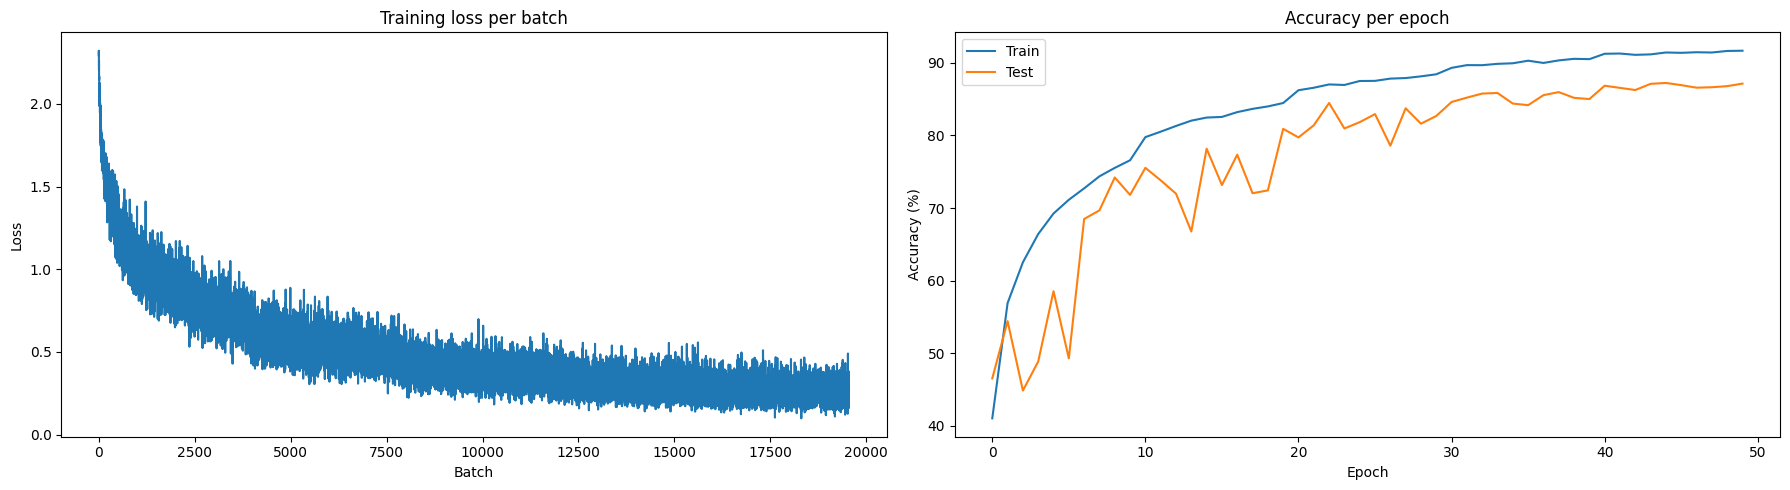


Final best test accuracy: 87.23%


In [12]:

model, history, batch_losses = train_model(epochs=50)